# Example 4.2: Two layer FFN

In [25]:
import torch
import numpy as np
import matplotlib.pylab as plt

## Set the features of the network and for learning

In [26]:
# features, labels, and hidden layer size
num_features = 2
num_labels = 2
num_hidden = 3

# number of data points
num_data = 8

# hyperparameters
lr = 0.05
num_epochs = 1000

## Generate training data

In [27]:
SEED = 10
np.random.seed(SEED)

# generate training data
X = torch.tensor(np.random.rand(num_data, num_features))
Y = torch.tensor(2*np.random.rand(num_data, num_labels) - 1)

print('x:{}'.format(X.numpy()))
print('y:{}'.format(Y.numpy()))

x:[[0.77132064 0.02075195]
 [0.63364823 0.74880388]
 [0.49850701 0.22479665]
 [0.19806286 0.76053071]
 [0.16911084 0.08833981]
 [0.68535982 0.95339335]
 [0.00394827 0.51219226]
 [0.81262096 0.61252607]]
y:[[ 0.44351063 -0.41624786]
 [ 0.83554825  0.42915157]
 [ 0.08508874 -0.7156599 ]
 [-0.25331848  0.34826723]
 [-0.11633365 -0.13197201]
 [ 0.23553396  0.02627649]
 [ 0.30079436  0.20207791]
 [ 0.61044639  0.0432943 ]]


## initialization routines for bias and weights

In [28]:
def init_bias(n = 1):
    return(torch.tensor(np.zeros(n), dtype=torch.double))

def init_weights(n_in=1, n_out=1, gain=4.0):
    W_values = np.asarray(np.random.uniform(low=-gain*np.sqrt(6. / (n_in + n_out)),
                                            high=gain*np.sqrt(6. / (n_in + n_out)),
                                            size=(n_in, n_out)))
    return(torch.tensor(W_values, dtype=torch.double))

## Define class for two-layer feedforward network

In [29]:
class Two_Layer_FFN():
  def __init__(self, num_features, num_hidden, num_labels):
    self.W = init_weights(num_features, num_hidden)
    self.b = init_bias(num_hidden)
    self.V = init_weights(num_hidden, num_labels)
    self.c = init_bias(num_labels)

  def __call__(self, x):
    z = torch.matmul(x, self.W) + self.b
    h = torch.sigmoid(z)
    y = torch.matmul(h, self.V) + self.c
    return z, h, y

## Define the loss function

In [30]:
def loss(targets, outputs):
    return torch.mean(torch.square(targets - outputs))

## Define one training epoch

In [31]:
def train(model, inputs, targets, learning_rate):
    z, h, y = model(inputs)
    grad_u = -(targets - y)
    grad_V = torch.matmul(torch.transpose(h, 0, 1), grad_u)
    grad_c = torch.sum(grad_u, axis=0)

    dh = h*(1-h)
    grad_z = torch.matmul(grad_u, torch.transpose(model.V, 0, 1))*dh
    grad_W = torch.matmul(torch.transpose(inputs, 0, 1), grad_z)
    grad_b = torch.sum(grad_z, axis=0)

    model.W -= learning_rate*grad_W
    model.b -= learning_rate*grad_b
    model.V -= learning_rate*grad_V
    model.c -= learning_rate*grad_c
    
    return grad_u, dh, grad_z, grad_V, grad_c, grad_W, grad_b
  

## Create the network

In [32]:
model = Two_Layer_FFN(num_features, num_hidden, num_labels)

print('W = {}, b = {}'.format(model.W.numpy(), model.b.numpy()))
print('V = {}, c = {}'.format(model.V.numpy(), model.c.numpy()))

W = [[ 3.58121936 -1.58413555 -3.58903444]
 [-1.7465772  -3.38287156  2.88041883]], b = [0. 0. 0.]
V = [[-3.97080171  1.10672512]
 [ 0.41702418  2.79809104]
 [-2.63829158  3.12727936]], c = [0. 0.]


## Train the network

In [33]:
err = []
for epoch in range(num_epochs):

    z_, h_, y_ = model(X)
    cost_ = loss(Y, y_)
    grad_u_, dh_, grad_z_, grad_V_, grad_c_, grad_W_, grad_b_ = train(model, X, Y, lr)
    
    if epoch == 0:
        print('iter: {}'.format(epoch+1))
        print('z: {}'.format(z_.detach().numpy()))
        print('h: {}'.format(h_.detach().numpy()))
        print('y: {}'.format(y_.detach().numpy()))
        print('grad_u: {}'.format(grad_u_.detach().numpy()))
        print('dh: {}'.format(dh_.detach().numpy()))
        print('grad_z:{}'.format(grad_z_.detach().numpy()))
        print('grad_V:{}'.format(grad_V_.detach().numpy()))
        print('grad_c:{}'.format(grad_c_.detach().numpy()))
        print('grad_W:{}'.format(grad_W_.detach().numpy()))
        print('grad_b:{}'.format(grad_b_.detach().numpy()))
        print('cost: {}'.format(cost_.item()))
        print('W = {}, b = {}'.format(model.W.numpy(), model.b.numpy()))
        print('V = {}, c = {}'.format(model.V.numpy(), model.c.numpy()))
        
    err.append(cost_)
    if not epoch%100:
        print('epoch: {}, m.s.e: {}'.format(epoch,err[epoch]))

iter: 1
z: [[ 2.72602354 -1.29207763 -2.70852205]
 [ 0.96138954 -3.53689205 -0.11731654]
 [ 1.39263827 -1.55016086 -1.14165035]
 [-0.61901903 -2.88653614  1.47979254]
 [ 0.4513307  -0.56673673 -0.35248895]
 [ 0.78924878 -4.31091009  0.28639215]
 [-0.88044372 -1.73893523  1.46115777]
 [ 1.84034986 -3.35939876 -1.15219301]]
h: [[0.93854488 0.21550136 0.06247236]
 [0.72339993 0.02828057 0.47070446]
 [0.80101309 0.17506304 0.24201748]
 [0.35000459 0.05282316 0.81454124]
 [0.61095557 0.36199015 0.41277899]
 [0.68767001 0.01324358 0.57111264]
 [0.29308584 0.14944823 0.81170969]
 [0.86299008 0.03358873 0.24008875]]
y: [[-3.80172664  1.83707213]
 [-4.10253959  2.35176082]
 [-3.74617133  2.13319991]
 [-3.51676759  3.08246089]
 [-3.36405611  2.97991647]
 [-4.23184001  2.5841472 ]
 [-3.24298906  3.28097818]
 [-4.04617929  1.79990173]]
grad_u: [[-4.24523727  2.25331999]
 [-4.93808784  1.92260926]
 [-3.83126007  2.84885981]
 [-3.26344911  2.73419366]
 [-3.24772246  3.11188849]
 [-4.46737397  2.5578

## Print final weights, biases, and predictions

In [34]:
print('W = {}, b = {}'.format(model.W.numpy(), model.b.numpy()))
print('V = {}, c = {}'.format(model.V.numpy(), model.c.numpy()))

_, _, y_ = model(X)
mse = loss(Y, y_)
print('m.s.e: {}'.format(mse))

W = [[ 0.3899948  -2.03832862 -2.0461922 ]
 [-3.3979316  -3.82428548  2.43348068]], b = [ 0.28282928 -2.18176498 -0.25309509]
V = [[-2.0373109  -0.71584374]
 [-0.31540349  1.71181135]
 [-2.07286945  0.86427901]], c = [ 1.87179702 -0.2854813 ]
m.s.e: 0.05289830645651625


## Plot learning curves

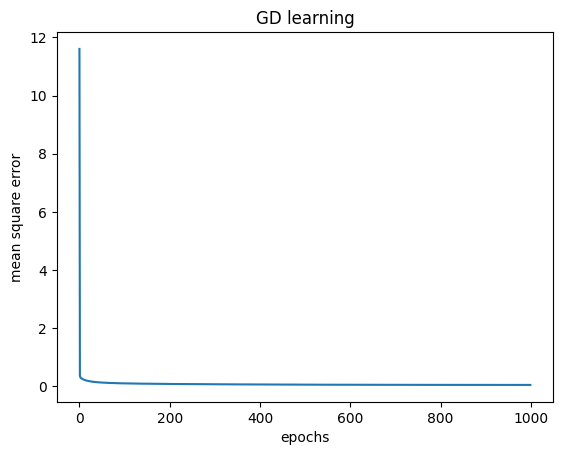

In [35]:
# plot learning curves
plt.figure(1)
plt.plot(range(num_epochs), err)
plt.xlabel('epochs')
plt.ylabel('mean square error')
plt.title('GD learning')
plt.show()

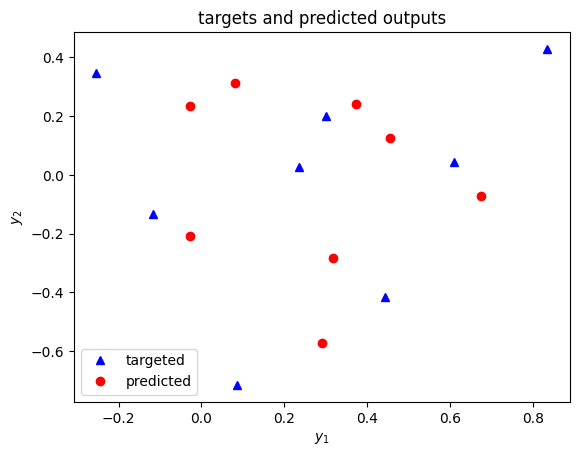

In [36]:
# plot trained and predicted points
_, _, y_ = model(X)
    
plt.figure(2)
plot_targets = plt.plot(Y[:,0], Y[:,1], 'b^', label='targeted')
plot_pred = plt.plot(y_[:,0], y_[:,1], 'ro', label='predicted')
plt.xlabel('$y_1$')
plt.ylabel('$y_2$')
plt.title('targets and predicted outputs')
plt.legend()
plt.show()